Model trained on 2218 samples (after SMOTE from 1583)
SHAP computed on 396 held-out test samples

Computing SHAP values (takes ~1 minute)...
SHAP values extracted — shape: (396, 36)
Expected: (396, 36)

SHAP values shape: (396, 36)
✓ SHAP values computed

SHAP FEATURE IMPORTANCE RANKING (PCOS class)
Rank  Feature                              Mean |SHAP|   Cumul. %
-----------------------------------------------------------------
  1    Fast Food Consumption                    0.07996      12.8%
  2    Excess Hair Growth                       0.06248      22.7%
  3    Skin Darkening                           0.06112      32.5%
  4    Menstrual Cycle (R/I)                    0.05776      41.7%
  5    Cycle Length (days)                      0.04763      49.3%
  6    Weight Gain (symptom)                    0.04538      56.5%
  7    AMH (ng/mL)                              0.04322      63.4%
  8     Age (yrs)                               0.02551      67.5%
  9    Beta-HCG I (mIU/mL)     

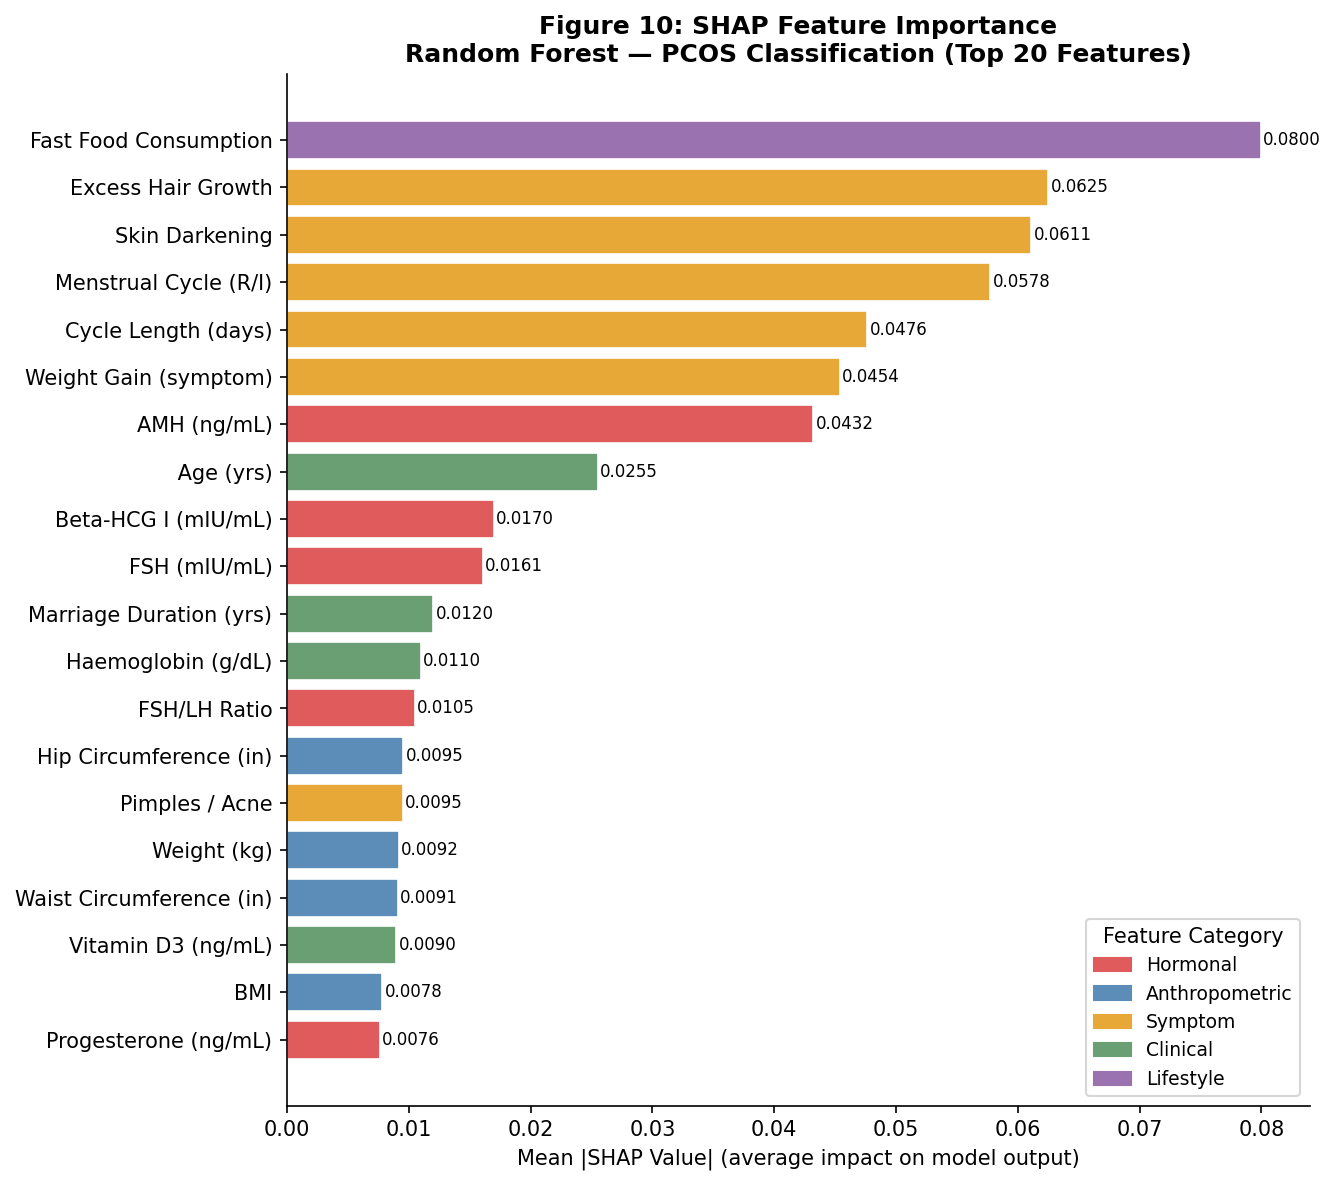


✓ Figure 10 saved


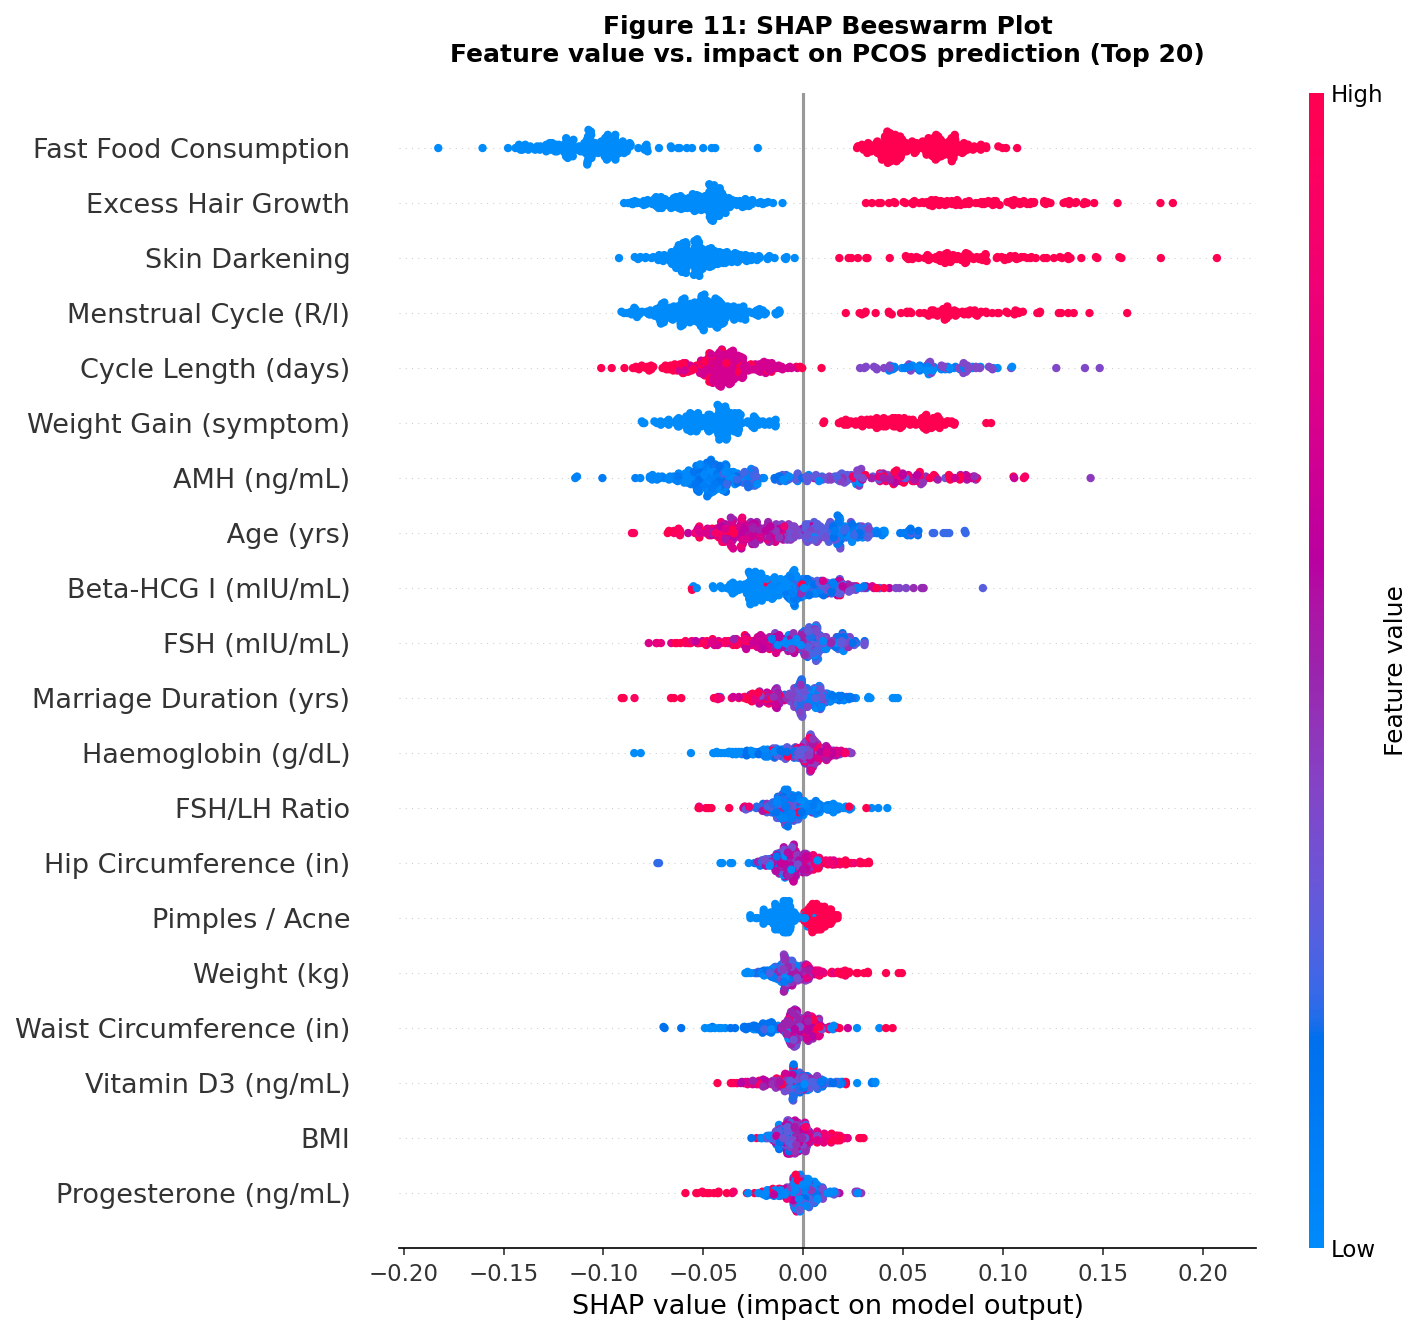

✓ Figure 11 saved


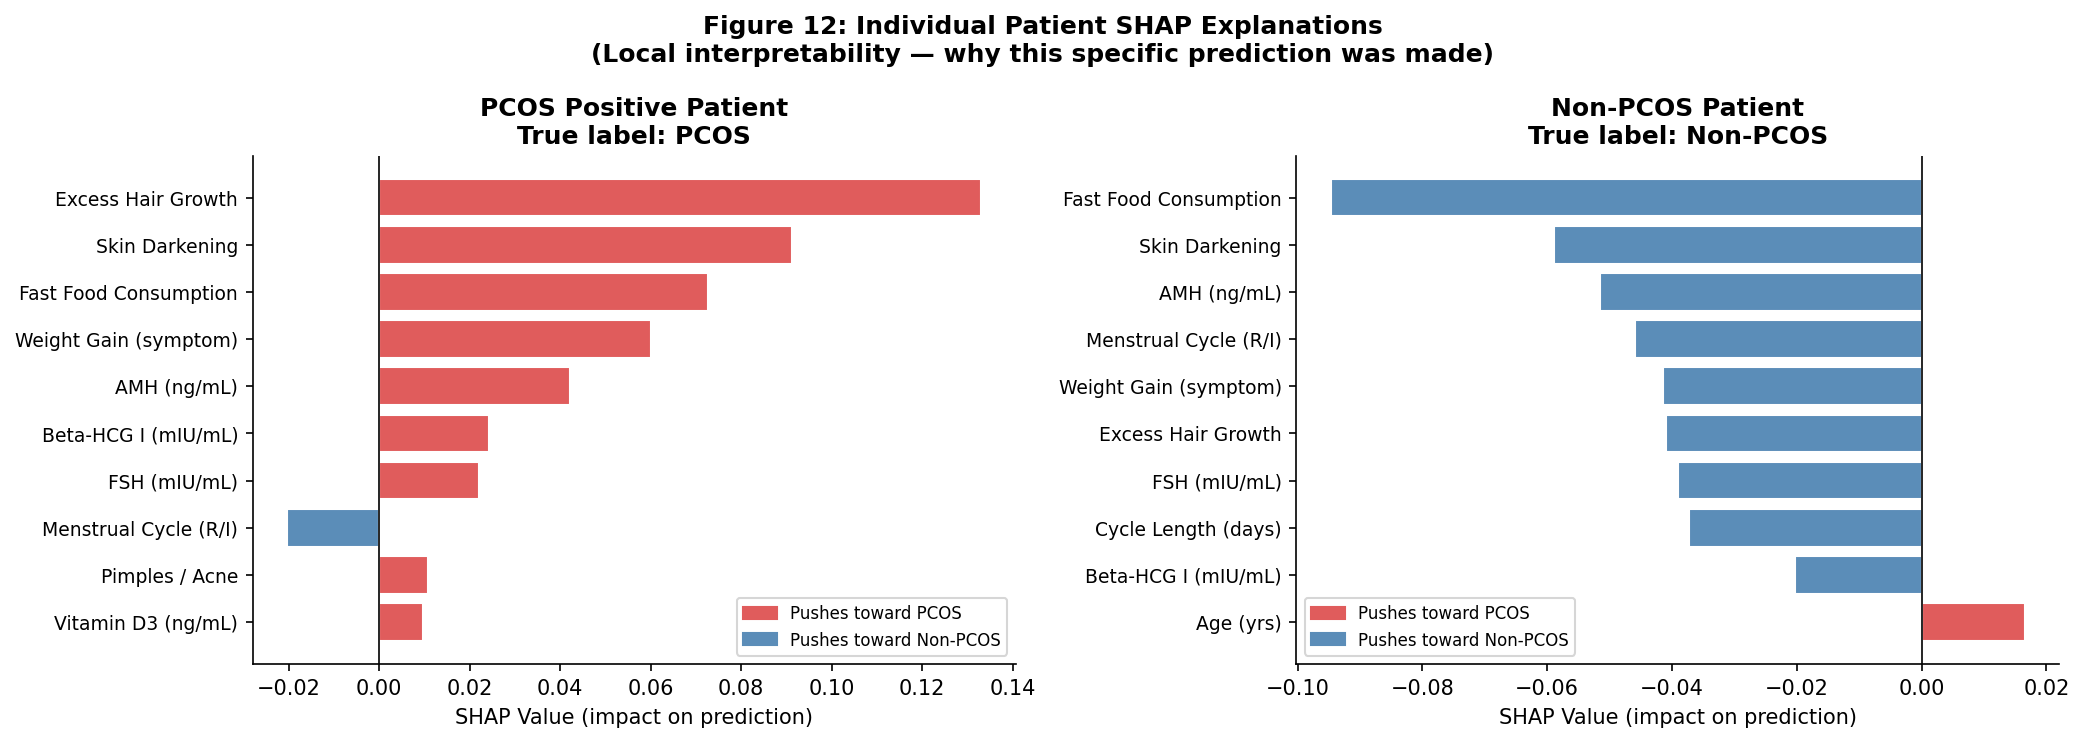

✓ Figure 12 saved

✓ SHAP results saved to step6_shap.pkl
✓ RF model and scaler saved for web app use
✓ Ready for Step 7: Feature Reduction Study


In [ ]:
# ============================================================
# STEP 6: SHAP EXPLAINABILITY ANALYSIS
# PCOS Classification Project
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import shap
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# ── Install SHAP if needed ────────────────────────────────────
# !pip install shap -q

# ── Load data ─────────────────────────────────────────────────
df     = pd.read_csv('PCOS_clean.csv')
target = 'PCOS (Y/N)'
X      = df.drop(columns=[target])
y      = df[target]

feature_names = list(X.columns)

# ── Clean feature names for display ───────────────────────────
name_map = {
    'Age (yrs)':              'Age (years)',
    'Weight (Kg)':            'Weight (kg)',
    'Height(Cm) ':            'Height (cm)',
    'BMI':                    'BMI',
    'Blood Group':            'Blood Group',
    'Pulse rate(bpm) ':       'Pulse Rate (bpm)',
    'RR (breaths/min)':       'Respiratory Rate',
    'Hb(g/dl)':               'Haemoglobin (g/dL)',
    'Cycle(R/I)':             'Menstrual Cycle (R/I)',
    'Cycle length(days)':     'Cycle Length (days)',
    'Marraige Status (Yrs)':  'Marriage Duration (yrs)',
    'Pregnant(Y/N)':          'Currently Pregnant',
    'No. of abortions':       'No. of Abortions',
    '  I   beta-HCG(mIU/mL)':'Beta-HCG I (mIU/mL)',
    'II    beta-HCG(mIU/mL)': 'Beta-HCG II (mIU/mL)',
    'FSH(mIU/mL)':            'FSH (mIU/mL)',
    'LH(mIU/mL)':             'LH (mIU/mL)',
    'FSH/LH':                 'FSH/LH Ratio',
    'Hip(inch)':              'Hip Circumference (in)',
    'Waist(inch)':            'Waist Circumference (in)',
    'Waist:Hip Ratio':        'Waist-Hip Ratio',
    'TSH (mIU/L)':            'TSH (mIU/L)',
    'AMH(ng/mL)':             'AMH (ng/mL)',
    'PRL(ng/mL)':             'Prolactin (ng/mL)',
    'Vit D3 (ng/mL)':         'Vitamin D3 (ng/mL)',
    'PRG(ng/mL)':             'Progesterone (ng/mL)',
    'RBS(mg/dl)':             'Random Blood Sugar (mg/dL)',
    'Weight gain(Y/N)':       'Weight Gain (symptom)',
    'hair growth(Y/N)':       'Excess Hair Growth',
    'Skin darkening (Y/N)':   'Skin Darkening',
    'Hair loss(Y/N)':         'Hair Loss',
    'Pimples(Y/N)':           'Pimples / Acne',
    'Fast food (Y/N)':        'Fast Food Consumption',
    'Reg.Exercise(Y/N)':      'Regular Exercise',
    'BP _Systolic (mmHg)':    'Systolic BP (mmHg)',
    'BP _Diastolic (mmHg)':   'Diastolic BP (mmHg)',
}

display_names = [name_map.get(f, f) for f in feature_names]

# ── Rename columns for clean SHAP plots ───────────────────────
X_display = X.rename(columns=name_map)

# ════════════════════════════════════════════════════════════
# TRAIN FINAL RF MODEL ON 80% SPLIT
#
# SHAP requires a fitted model on actual data (not CV fold).
# We train on 80%, compute SHAP on the 20% test set.
# This is standard practice — SHAP explains test predictions.
# ════════════════════════════════════════════════════════════
X_tr, X_te, y_tr, y_te = train_test_split(
    X_display, y,
    test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE only to training data
smote = SMOTE(random_state=42, k_neighbors=5)
X_tr_res, y_tr_res = smote.fit_resample(X_tr, y_tr)

# Scale
scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_tr_res)
X_te_sc  = scaler.transform(X_te)

# Train RF
rf = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_tr_sc, y_tr_res)

# Wrap back as DataFrame for SHAP display
X_tr_sc_df = pd.DataFrame(X_tr_sc,  columns=X_display.columns)
X_te_sc_df = pd.DataFrame(X_te_sc,  columns=X_display.columns)

print(f"Model trained on {len(X_tr_res)} samples "
      f"(after SMOTE from {len(X_tr)})")
print(f"SHAP computed on {len(X_te)} held-out test samples\n")

# ════════════════════════════════════════════════════════════
# COMPUTE SHAP VALUES
# TreeExplainer is exact (not approximate) for tree models
# ════════════════════════════════════════════════════════════
print("Computing SHAP values (takes ~1 minute)...")
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_te_sc_df)

# For binary classification RF, shap_values is a list [class0, class1]
# We want class 1 (PCOS positive)
# WITH THIS:
if isinstance(shap_values, list):
    sv = shap_values[1]        # older SHAP: list of [class0, class1]
elif shap_values.ndim == 3:
    sv = shap_values[:, :, 1]  # newer SHAP: shape (samples, features, classes)
else:
    sv = shap_values           # already 2D

print(f"SHAP values extracted — shape: {sv.shape}")
print(f"Expected: ({len(X_te)}, {len(X_display.columns)})\n")

print(f"SHAP values shape: {sv.shape}")
print("✓ SHAP values computed\n")

# ════════════════════════════════════════════════════════════
# GLOBAL FEATURE IMPORTANCE TABLE
# ════════════════════════════════════════════════════════════
mean_abs_shap = np.abs(sv).mean(axis=0)
shap_df = pd.DataFrame({
    'Feature':        X_display.columns,
    'Mean |SHAP|':    mean_abs_shap,
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

shap_df['Rank'] = shap_df.index + 1
shap_df['Cumulative Importance (%)'] = (
    shap_df['Mean |SHAP|'].cumsum() /
    shap_df['Mean |SHAP|'].sum() * 100
).round(1)

print("=" * 65)
print("SHAP FEATURE IMPORTANCE RANKING (PCOS class)")
print("=" * 65)
print(f"{'Rank':<5} {'Feature':<35} "
      f"{'Mean |SHAP|':>12} {'Cumul. %':>10}")
print("-" * 65)
for _, row in shap_df.iterrows():
    print(f"  {int(row['Rank']):<4} {row['Feature']:<35} "
          f"{row['Mean |SHAP|']:>12.5f} "
          f"{row['Cumulative Importance (%)']:>9.1f}%")
print("=" * 65)

# Identify where 80% and 90% cumulative importance is reached
thresh_80 = shap_df[shap_df['Cumulative Importance (%)'] >= 80].iloc[0]
thresh_90 = shap_df[shap_df['Cumulative Importance (%)'] >= 90].iloc[0]
print(f"\n80% of predictive importance captured by top "
      f"{int(thresh_80['Rank'])} features")
print(f"90% of predictive importance captured by top "
      f"{int(thresh_90['Rank'])} features")

# ════════════════════════════════════════════════════════════
# FIGURE 10 — SHAP Bar Plot (Global Importance, Top 20)
# ════════════════════════════════════════════════════════════
plt.rcParams.update({
    'font.size': 10, 'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 150, 'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

top20 = shap_df.head(20)

# Colour by feature category
category_colors = {
    'Hormonal':    '#E05C5C',
    'Anthropometric': '#5B8DB8',
    'Symptom':     '#E8A838',
    'Clinical':    '#6A9E73',
    'Lifestyle':   '#9B72B0',
}

hormonal_feats = {
    'AMH (ng/mL)', 'FSH (mIU/mL)', 'LH (mIU/mL)',
    'FSH/LH Ratio', 'TSH (mIU/L)', 'Prolactin (ng/mL)',
    'Progesterone (ng/mL)', 'Beta-HCG I (mIU/mL)',
    'Beta-HCG II (mIU/mL)'
}
anthropometric_feats = {
    'BMI', 'Weight (kg)', 'Height (cm)',
    'Waist Circumference (in)', 'Hip Circumference (in)',
    'Waist-Hip Ratio'
}
symptom_feats = {
    'Excess Hair Growth', 'Skin Darkening', 'Hair Loss',
    'Pimples / Acne', 'Weight Gain (symptom)',
    'Menstrual Cycle (R/I)', 'Cycle Length (days)'
}
lifestyle_feats = {
    'Fast Food Consumption', 'Regular Exercise'
}

def get_color(feat):
    if feat in hormonal_feats:      return category_colors['Hormonal']
    if feat in anthropometric_feats: return category_colors['Anthropometric']
    if feat in symptom_feats:       return category_colors['Symptom']
    if feat in lifestyle_feats:     return category_colors['Lifestyle']
    return category_colors['Clinical']

bar_colors = [get_color(f) for f in top20['Feature']]

fig, ax = plt.subplots(figsize=(9, 8))
bars = ax.barh(
    range(len(top20)),
    top20['Mean |SHAP|'].values[::-1] if False
    else top20['Mean |SHAP|'].values,
    color=bar_colors,
    edgecolor='white', linewidth=0.8
)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['Feature'].values, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Mean |SHAP Value| (average impact on model output)')
ax.set_title('Figure 10: SHAP Feature Importance\n'
             'Random Forest — PCOS Classification (Top 20 Features)')

# Legend
patches = [mpatches.Patch(color=c, label=cat)
           for cat, c in category_colors.items()]
ax.legend(handles=patches, loc='lower right',
          fontsize=9, title='Feature Category')

for bar, val in zip(bars, top20['Mean |SHAP|'].values):
    ax.text(val + 0.0002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('fig10_shap_importance.png')
plt.show()
print("\n✓ Figure 10 saved")

# ════════════════════════════════════════════════════════════
# FIGURE 11 — SHAP Beeswarm Plot
# Shows direction of effect (high/low feature value → PCOS risk)
# ════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 9))

# Get top 20 feature indices by mean |SHAP|
top20_idx = shap_df.head(20).index.tolist()
# Re-index to match original order in sv
top20_feat_order = shap_df.head(20)['Feature'].tolist()
top20_col_idx    = [list(X_display.columns).index(f)
                    for f in top20_feat_order]

shap.summary_plot(
    sv[:, top20_col_idx],
    X_te_sc_df.iloc[:, top20_col_idx],
    feature_names=top20_feat_order,
    max_display=20,
    show=False,
    plot_size=(10, 9)
)
plt.title('Figure 11: SHAP Beeswarm Plot\n'
          'Feature value vs. impact on PCOS prediction (Top 20)',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig11_shap_beeswarm.png')
plt.show()
print("✓ Figure 11 saved")

# ════════════════════════════════════════════════════════════
# FIGURE 12 — SHAP for a Single Patient (local explanation)
# Pick one PCOS-positive and one PCOS-negative patient
# ════════════════════════════════════════════════════════════
# Find index of a clear PCOS positive in test set
pcos_idx    = np.where(y_te.values == 1)[0][0]
nopcos_idx  = np.where(y_te.values == 0)[0][0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pat_idx, label in zip(
        axes,
        [pcos_idx, nopcos_idx],
        ['PCOS Positive Patient', 'Non-PCOS Patient']):

    patient_shap = sv[pat_idx]
    patient_feat = X_te_sc_df.iloc[pat_idx]

    # Take top 10 contributors for this patient
    top10_idx  = np.argsort(np.abs(patient_shap))[-10:][::-1]
    top10_shap = patient_shap[top10_idx]
    top10_feat = [X_display.columns[i] for i in top10_idx]

    bar_c = ['#E05C5C' if v > 0 else '#5B8DB8'
             for v in top10_shap]
    ax.barh(range(len(top10_shap)), top10_shap[::-1],
            color=bar_c[::-1], edgecolor='white')
    ax.set_yticks(range(len(top10_feat)))
    ax.set_yticklabels(top10_feat[::-1], fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('SHAP Value (impact on prediction)')
    ax.set_title(f'{label}\n'
                 f'True label: {"PCOS" if y_te.values[pat_idx]==1 else "Non-PCOS"}',
                 fontweight='bold')

    red_p  = mpatches.Patch(color='#E05C5C',
                             label='Pushes toward PCOS')
    blue_p = mpatches.Patch(color='#5B8DB8',
                             label='Pushes toward Non-PCOS')
    ax.legend(handles=[red_p, blue_p], fontsize=8)

plt.suptitle('Figure 12: Individual Patient SHAP Explanations\n'
             '(Local interpretability — why this specific prediction was made)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig12_shap_local.png')
plt.show()
print("✓ Figure 12 saved")

# ════════════════════════════════════════════════════════════
# SAVE SHAP RESULTS
# ════════════════════════════════════════════════════════════
with open('step6_shap.pkl', 'wb') as f:
    pickle.dump({
        'shap_values':    sv,
        'shap_df':        shap_df,
        'X_test':         X_te_sc_df,
        'y_test':         y_te,
        'explainer':      explainer,
        'scaler':         scaler,
        'rf_model':       rf,
        'feature_names':  list(X_display.columns),
        'thresh_80_rank': int(thresh_80['Rank']),
        'thresh_90_rank': int(thresh_90['Rank']),
    }, f)

print("\n✓ SHAP results saved to step6_shap.pkl")
print("✓ RF model and scaler saved for web app use")
print("✓ Ready for Step 7: Feature Reduction Study")